# Exercise 1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

*1.Draw a histogram for the variable age. At which age range are customers most concentrated?*


In [2]:
df = pd.read_csv('Lab1_Ex1_bank.csv', sep=';')
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


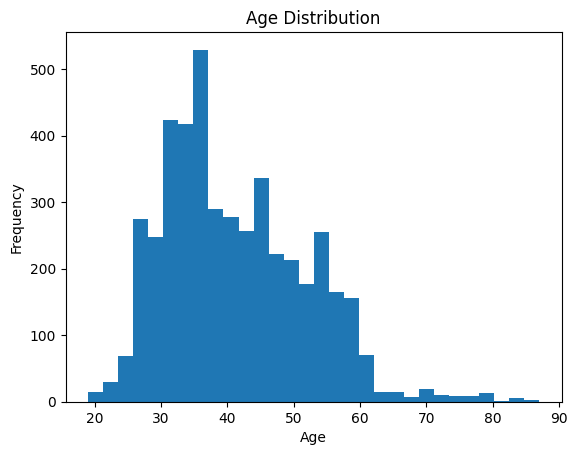

count    4521.000000
mean       41.170095
std        10.576211
min        19.000000
25%        33.000000
50%        39.000000
75%        49.000000
max        87.000000
Name: age, dtype: float64

In [3]:
plt.hist(df['age'], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

df['age'].describe()

**Answer:**

Customers are most concentrated between **30–40 years old**.

*2. Draw a histogram for balance. Are there many outliers ?*


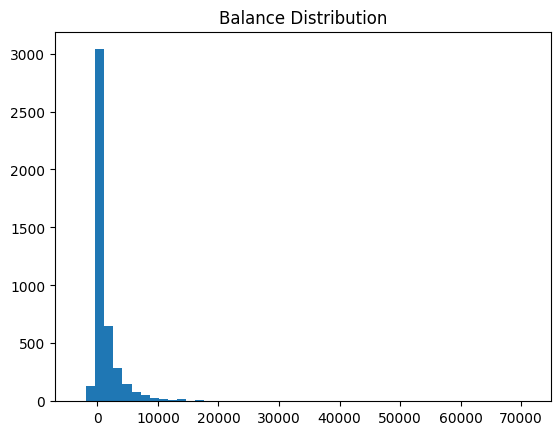

<Axes: ylabel='balance'>

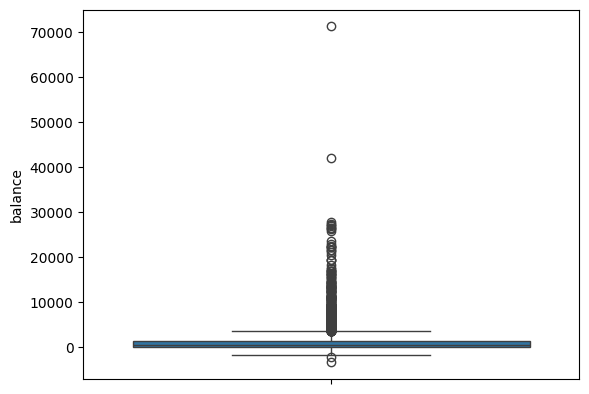

In [4]:
plt.hist(df['balance'], bins=50)
plt.title("Balance Distribution")
plt.show()

sns.boxplot(df['balance'])

In [5]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: -2047.5
Upper: 3596.5


In [6]:
outliers = df[(df['balance'] < lower_bound) | (df['balance'] > upper_bound)]

print(len(outliers))
outliers

506


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
10,39,services,married,secondary,no,9374,yes,no,unknown,20,may,273,1,-1,0,unknown,no
16,56,technician,married,secondary,no,4073,no,no,cellular,27,aug,239,5,-1,0,unknown,no
25,41,management,married,tertiary,no,5883,no,no,cellular,20,nov,182,2,-1,0,unknown,no
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4464,53,services,divorced,secondary,no,4554,no,no,cellular,5,feb,8,6,-1,0,unknown,no
4473,33,technician,married,secondary,no,4790,yes,no,cellular,20,apr,137,1,272,2,failure,no
4489,45,management,married,tertiary,no,6945,no,no,cellular,5,aug,131,5,356,3,failure,no
4500,38,admin.,married,secondary,no,4196,yes,no,cellular,12,may,193,2,-1,0,unknown,no


**Answer:**
Using the IQR method:
- Lower bound = -2047.5
- Upper bound = 3596.5

Values outside this range are considered outliers. There are **506 outliers** in the dataset.

*3. Draw a bar chart for job. Which occupation has the highest proportion?*

In [7]:
df['job'].value_counts(normalize=True) 

job
management       0.214333
blue-collar      0.209246
technician       0.169874
admin.           0.105729
services         0.092236
retired          0.050874
self-employed    0.040478
entrepreneur     0.037160
unemployed       0.028312
housemaid        0.024773
student          0.018580
unknown          0.008405
Name: proportion, dtype: float64

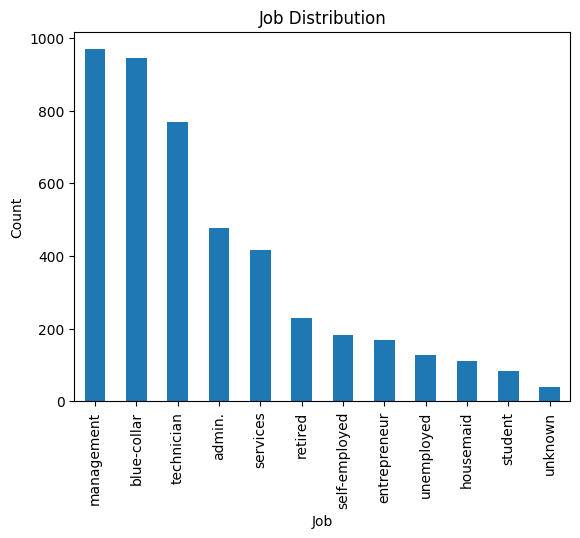

In [8]:
df['job'].value_counts().plot(kind='bar')

plt.xlabel("Job")
plt.ylabel("Count")
plt.title("Job Distribution")
plt.show()

**Answer:**

The bar chart shows the distribution of occupations among customers. 
Using value_counts(normalize=True), we can observe the proportion of each job category.

The occupation with the highest proportion is **management**.

*4. Draw a scatter plot between balance and age. Is there any relationship?*

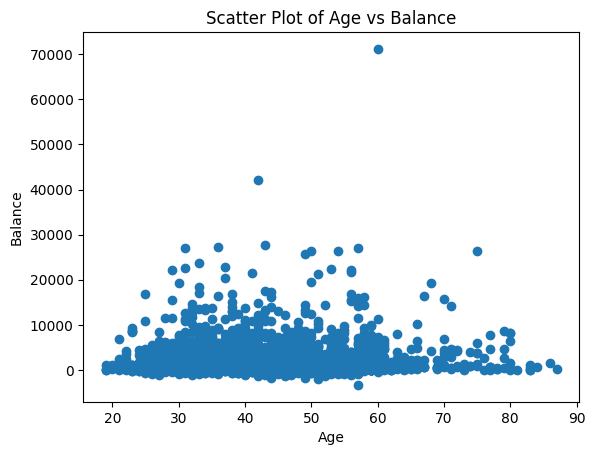

In [9]:
plt.scatter(df['age'], df['balance'])
plt.xlabel("Age")
plt.ylabel("Balance")
plt.title("Scatter Plot of Age vs Balance")
plt.show()

In [10]:
df[['age','balance']].corr()

,age,balance
age,1.00000,0.08382
balance,0.08382,1.00000


**Answer:**
The correlation coefficient between age and balance is **0.08382**, which indicates a **very weak positive relationship**. 

Therefore, there is **no strong relationship between age and balance**.

*5. Draw a heatmap of the correlation matrix among numerical attributes.*

In [11]:
corr = df.corr(numeric_only=True)
corr

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.083820,-0.017853,-0.002367,-0.005148,-0.008894,-0.003511
balance,0.083820,1.000000,-0.008677,-0.015950,-0.009976,0.009437,0.026196
day,-0.017853,-0.008677,1.000000,-0.024629,0.160706,-0.094352,-0.059114
duration,-0.002367,-0.015950,-0.024629,1.000000,-0.068382,0.010380,0.018080
campaign,-0.005148,-0.009976,0.160706,-0.068382,1.000000,-0.093137,-0.067833
pdays,-0.008894,0.009437,-0.094352,0.010380,-0.093137,1.000000,0.577562
previous,-0.003511,0.026196,-0.059114,0.018080,-0.067833,0.577562,1.000000


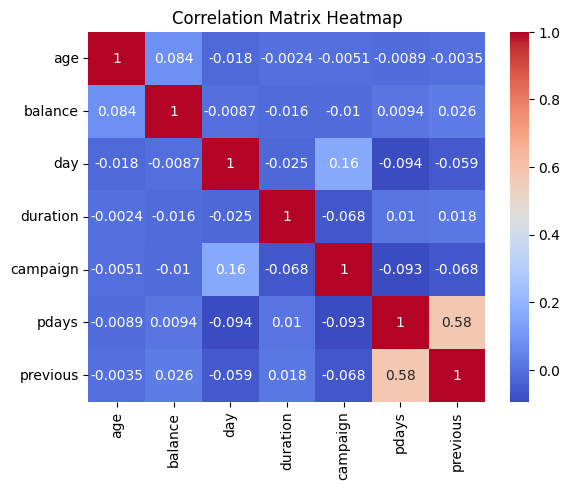

In [12]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix Heatmap")
plt.show()

**Answer:**

The heatmap shows the correlation matrix among the numerical attributes. 
Most correlation values are close to zero, indicating weak relationships between the variables.

One notable correlation is between **pdays and previous (0.58)**, which suggests a moderate positive relationship. 
This means customers who were contacted previously tend to have a larger number of days since last contact.

Other variables, such as **age and balance (0.084)**, show only a very weak relationship.

*6. How does the number of contacts (campaign) affect the outcome y ?*

In [13]:
pd.crosstab(df['campaign'], df['y'], normalize='index')

y,no,yes
campaign,,
1,0.861592,0.138408
2,0.890823,0.109177
3,0.897849,0.102151
4,0.867692,0.132308
5,0.946108,0.053892
6,0.896774,0.103226
7,0.920000,0.080000
8,0.928571,0.071429
9,0.933333,0.066667


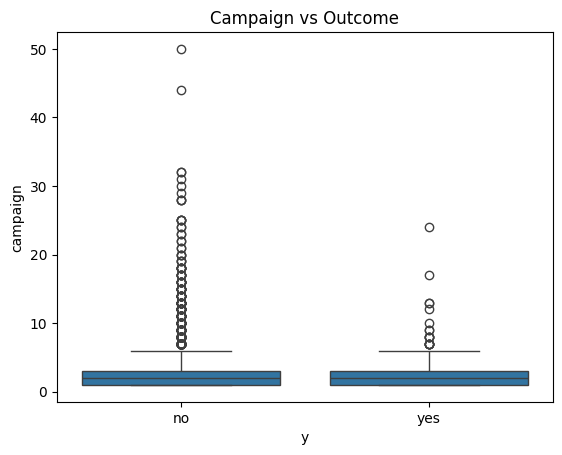

In [14]:
sns.boxplot(x='y', y='campaign', data=df)

plt.title("Campaign vs Outcome")
plt.show()

**Answer:**

From the crosstab results, customers contacted only a few times have a higher probability of subscribing. For example, when campaign = 1, the success rate is about **13.8%**, but the proportion of "yes" responses decreases as the number of contacts increases.

The boxplot also shows that customers who did not subscribe (y = no) tend to have a larger number of campaign contacts and more extreme values.

Overall, contacting customers too many times does not increase the success rate and may even reduce the likelihood of a positive outcome.

*7. Which month has the highest subscription rate?*

In [15]:
pd.crosstab(df['month'], df['y'], normalize='index')

y,no,yes
month,,
apr,0.808874,0.191126
aug,0.875197,0.124803
dec,0.550000,0.450000
feb,0.828829,0.171171
jan,0.891892,0.108108
jul,0.913598,0.086402
jun,0.896422,0.103578
mar,0.571429,0.428571
may,0.933476,0.066524


In [16]:
pd.crosstab(df['month'], df['y'], normalize='index')\
    .sort_values(by='yes', ascending=False)

y,no,yes
month,,
oct,0.537500,0.462500
dec,0.550000,0.450000
mar,0.571429,0.428571
sep,0.673077,0.326923
apr,0.808874,0.191126
feb,0.828829,0.171171
aug,0.875197,0.124803
jan,0.891892,0.108108
jun,0.896422,0.103578


**Answer:**

Based on the crosstab results, **October (oct)** has the highest subscription rate, with about **46.25%** of contacted customers subscribing to the term deposit.

*8. Average call duration by month.*

In [17]:
df.groupby('month')['duration'].mean()

month
apr    294.354949
aug    243.742496
dec    416.900000
feb    255.698198
jan    269.540541
jul    271.205382
jun    252.425612
mar    198.897959
may    267.316166
nov    272.066838
oct    272.800000
sep    215.730769
Name: duration, dtype: float64

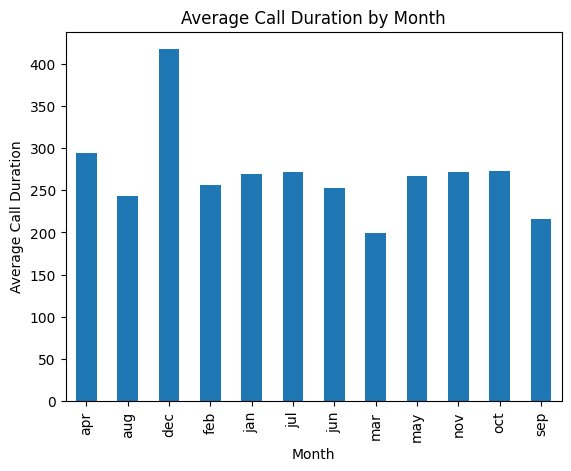

In [18]:
df.groupby('month')['duration'].mean().plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Average Call Duration")
plt.title("Average Call Duration by Month")
plt.show()

*9. How many records and how many attributes does the dataset contain ?*

In [19]:
df.shape 

(4521, 17)

In [20]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


**Answer:**

The dataset contains **4521 records** and **17 attributes**.

*10. Check for missing values ?*

In [21]:
df.isnull().sum() 

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [22]:
df.eq('unknown').sum()

age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64

**Answer:**

The dataset does not contain true missing values (NaN). 
However, some attributes contain the value **"unknown"**, which represents missing or unavailable information.

*11. What is the target variable ?*

**Answer:**

The target variable is **y**, which indicates whether the customer subscribed to a term deposit.

* y = yes → customer subscribed
* y = no → customer did not subscribe

*12. Are there any abnormal negative values (e.g., balance = -88) ?*

In [23]:
df[df['balance'] < 0] # customer overdraft / debt

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no
48,32,entrepreneur,single,primary,yes,-849,yes,yes,cellular,4,feb,204,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
92,27,services,single,secondary,no,-195,yes,no,cellular,18,may,391,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4474,44,blue-collar,married,primary,no,-237,yes,no,telephone,10,jul,73,1,-1,0,unknown,no
4502,42,services,married,secondary,no,-91,yes,yes,cellular,5,feb,43,1,-1,0,unknown,no
4506,42,unemployed,divorced,tertiary,no,-166,no,no,cellular,29,aug,85,4,-1,0,unknown,no
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no


In [24]:
df.describe() 

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


**Answer:**

Yes, there are some negative values in the **balance** attribute. They may represent customers who have an overdraft or negative account balance.

*13. Check and handle the value: pdays = -1. What does it mean ? Should it be replaced 
or converted to NaN ?*

In [25]:
df['pdays'].value_counts()

pdays
-1      3705
 182      23
 183      20
 363      12
 92       12
        ... 
 118       1
 386       1
 63        1
 81        1
 234       1
Name: count, Length: 292, dtype: int64

In [26]:
df['pdays'] = df['pdays'].replace(-1, np.nan)

**Answer:**

The value `-1` in the `pdays` variable indicates that the customer was **not previously contacted**.

In this dataset, `-1` appears **3705 times**, meaning most customers have not been contacted before. Since `-1` is not a valid number of days, it should be replaced with **NaN** to represent missing information.

*14. Handle "unknown" values in columns such as: contact, poutcome*

In [27]:
df = df.replace('unknown', np.nan)

In [28]:
df = df.fillna(df.mode().iloc[0])

*15. Check for duplicate records and remove them if any.*

In [29]:
df.duplicated().sum() 

0

In [30]:
df = df.drop_duplicates()

*16. Check and handle outliers in: balance, duration*

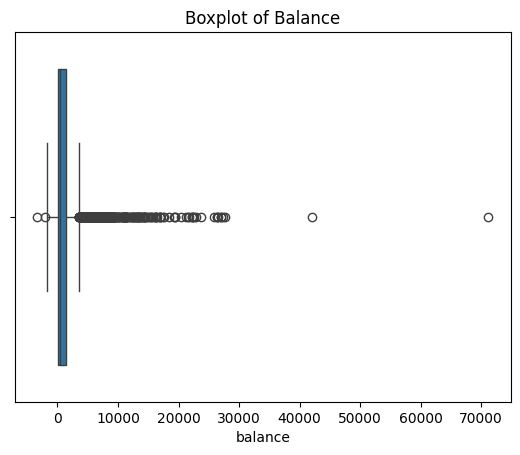

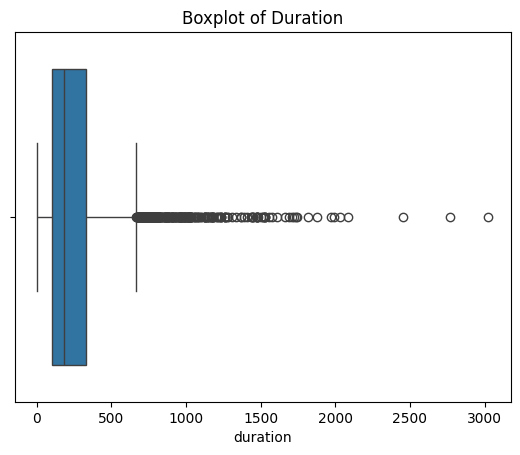

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['balance'])
plt.title("Boxplot of Balance")
plt.show()

sns.boxplot(x=df['duration'])
plt.title("Boxplot of Duration")
plt.show()

In [32]:
def iqr_bounds(s):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return lower, upper

bal_low, bal_up = iqr_bounds(df['balance'])
dur_low, dur_up = iqr_bounds(df['duration'])

print("Balance bounds:", bal_low, bal_up)
print("Duration bounds:", dur_low, dur_up)

bal_outliers = df[(df['balance'] < bal_low) | (df['balance'] > bal_up)]
dur_outliers = df[(df['duration'] < dur_low) | (df['duration'] > dur_up)]

print("Balance outliers:", len(bal_outliers))
print("Duration outliers:", len(dur_outliers))

Balance bounds: -2047.5 3596.5
Duration bounds: -233.5 666.5
Balance outliers: 506
Duration outliers: 330


In [33]:
df['balance'] = np.clip(df['balance'], bal_low, bal_up)
df['duration'] = np.clip(df['duration'], dur_low, dur_up)

new_balance_outliers = df[(df['balance'] < bal_low) | (df['balance'] > bal_up)]
print("New Balance outliers:", len(new_balance_outliers))

new_duration_outliers = df[(df['duration'] < dur_low) | (df['duration'] > dur_up)]
print("New Duration outliers:", len(new_duration_outliers))

New Balance outliers: 0
New Duration outliers: 0


**Answer:**

Outliers in the variables **balance** and **duration** were detected using the IQR method.

Initially:
- Balance outliers: **506**
- Duration outliers: **330**

To handle these extreme values, we applied **clipping**, which caps values outside the IQR bounds.

After applying clipping, no values remain outside the acceptable range.

*17. Normalize numerical variables: age, balance, duration*

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['age', 'balance', 'duration']] = scaler.fit_transform(df[['age', 'balance', 'duration']])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0.161765,unemployed,married,primary,no,0.679394,no,no,cellular,19,oct,0.113208,1,182.0,0,failure,no
1,0.205882,services,married,secondary,no,1.000000,yes,yes,cellular,11,may,0.326038,1,339.0,4,failure,no
2,0.235294,management,single,tertiary,no,0.601967,yes,no,cellular,16,apr,0.273208,1,330.0,1,failure,no
3,0.161765,management,married,tertiary,no,0.624291,yes,yes,cellular,3,jun,0.294340,4,182.0,0,failure,no
4,0.588235,blue-collar,married,secondary,no,0.362775,yes,no,cellular,5,may,0.335094,1,182.0,0,failure,no


*18. Encode categorical variables: job, marital, education, housing, loan Should you use 
Label Encoding or One-hot Encoding ? Why ?*

In [35]:
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'housing', 'loan'], drop_first=False)
print(df.columns)

Index(['age', 'default', 'balance', 'contact', 'day', 'month', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_divorced',
       'marital_married', 'marital_single', 'education_primary',
       'education_secondary', 'education_tertiary', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes'],
      dtype='object')


**Answer:**
After encoding, each category is represented by a binary column (e.g., `job_admin.`, `marital_single`, `education_primary`, etc.).

One-hot encoding is preferred because these variables are **nominal variables without an inherent order**, and label encoding could introduce a misleading ordinal relationship.

*19. Convert the variable month into numeric form (1 - 12).*

In [36]:
dict = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}
df['month'] = df['month'].map(dict)
df.head()

,age,default,balance,contact,day,month,duration,campaign,pdays,previous,...,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,housing_no,housing_yes,loan_no,loan_yes
0,0.161765,no,0.679394,cellular,19,10,0.113208,1,182.0,0,...,False,True,False,True,False,False,True,False,True,False
1,0.205882,no,1.000000,cellular,11,5,0.326038,1,339.0,4,...,False,True,False,False,True,False,False,True,False,True
2,0.235294,no,0.601967,cellular,16,4,0.273208,1,330.0,1,...,False,False,True,False,False,True,False,True,True,False
3,0.161765,no,0.624291,cellular,3,6,0.294340,4,182.0,0,...,False,True,False,False,False,True,False,True,False,True
4,0.588235,no,0.362775,cellular,5,5,0.335094,1,182.0,0,...,False,True,False,False,True,False,False,True,True,False


*20. Create new variables: Age group (young, middle, senior), Total number of contacts 
(campaign + previous) and Binary variable: whether previously contacted or not.*

In [37]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 50, 100],
    labels=['young', 'middle', 'senior']
)

In [38]:
df['total_contacts'] = df['campaign'] + df['previous']

In [39]:
df['previously_contacted'] = np.where(df['previous'] > 0, 1, 0)

In [40]:
df.head()

,age,default,balance,contact,day,month,duration,campaign,pdays,previous,...,education_primary,education_secondary,education_tertiary,housing_no,housing_yes,loan_no,loan_yes,age_group,total_contacts,previously_contacted
0,0.161765,no,0.679394,cellular,19,10,0.113208,1,182.0,0,...,True,False,False,True,False,True,False,young,1,0
1,0.205882,no,1.000000,cellular,11,5,0.326038,1,339.0,4,...,False,True,False,False,True,False,True,young,5,1
2,0.235294,no,0.601967,cellular,16,4,0.273208,1,330.0,1,...,False,False,True,False,True,True,False,young,2,1
3,0.161765,no,0.624291,cellular,3,6,0.294340,4,182.0,0,...,False,False,True,False,True,False,True,young,4,0
4,0.588235,no,0.362775,cellular,5,5,0.335094,1,182.0,0,...,False,True,False,False,True,True,False,young,1,0


**Answer:**

- `age_group` (young/middle/senior) to capture age patterns in broader segments,
- `total_contacts` = campaign + previous to represent total contact attempts,
- `previously_contacted` (0/1) to indicate whether the customer had been contacted before.

*21. Create variable: duration_per_campaign = duration / campaign*

In [41]:
df['duration_per_campaign'] = df['duration'] / df['campaign']

In [42]:
df['duration_per_campaign'] = df['duration'] / df['campaign'].replace(0, np.nan)
df['duration_per_campaign'] = df['duration_per_campaign'].fillna(0)

In [43]:
df.head()

,age,default,balance,contact,day,month,duration,campaign,pdays,previous,...,education_secondary,education_tertiary,housing_no,housing_yes,loan_no,loan_yes,age_group,total_contacts,previously_contacted,duration_per_campaign
0,0.161765,no,0.679394,cellular,19,10,0.113208,1,182.0,0,...,False,False,True,False,True,False,young,1,0,0.113208
1,0.205882,no,1.000000,cellular,11,5,0.326038,1,339.0,4,...,True,False,False,True,False,True,young,5,1,0.326038
2,0.235294,no,0.601967,cellular,16,4,0.273208,1,330.0,1,...,False,True,False,True,True,False,young,2,1,0.273208
3,0.161765,no,0.624291,cellular,3,6,0.294340,4,182.0,0,...,False,True,False,True,False,True,young,4,0,0.073585
4,0.588235,no,0.362775,cellular,5,5,0.335094,1,182.0,0,...,True,False,False,True,True,False,young,1,0,0.335094


**Answer (Q21):**

`duration_per_campaign = duration / campaign` to measure the average call duration per contact attempt.

*22. What is the ratio between y = yes and y = no ?*

In [44]:
df['y'].value_counts(normalize=True)

y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64

In [45]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

**Answer (Q22):**

The ratio of the target variable is:
- y = no: 88%
- y = yes: 12%
This indicates that the dataset is (imbalanced / relatively balanced).

*23. If the data is imbalanced, propose handling methods (undersampling, oversampling, 
SMOTE).*

In [46]:

from imblearn.under_sampling import RandomUnderSampler

X = df.drop('y', axis=1)
y = df['y']

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

In [47]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

In [48]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mode().iloc[0])
X = pd.get_dummies(X)

In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [50]:
y_res.value_counts()

y
no     4000
yes    4000
Name: count, dtype: int64

**Answer:**

The dataset is imbalanced because the number of "no" cases is much larger than the number of "yes" cases.

To address this issue, techniques such as **undersampling**, **oversampling**, and **SMOTE** can be used.

In this analysis, **SMOTE** was applied to generate synthetic samples for the minority class. After applying SMOTE, the dataset became balanced:

- no = 4000
- yes = 4000

This balanced dataset can help improve the performance of machine learning models.